# Occupancy Model Training

Trains RandomForest / SVM / XGBoost classifiers for person-count (0p/1p/2p)
on `engineered_csi_features.csv` (produced by `processing.py` from
`common/saif.py`'s cleaning + windowing pipeline, with **per-session baseline
normalization** already applied).

Uses a **session-level hold-out** split: entire recording sessions are kept
out of training and used only for test. This is the only honest measure of
cross-session generalization — splitting *within* one session leaks, because
adjacent time windows of a single recording are nearly identical and inflate
accuracy (which is what made the earlier model look good yet fail in
deployment).

Saves the deployed RandomForest model, scaler, and feature list to
`grad_dashboard/backend/models/` for the dashboard backend to load.

In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
)

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False

In [2]:
INPUT_CSV = "combined/engineered_csi_features.csv"
TEST_FRAC = 0.2
DIAG_SUFFIX = "_mean_sc_count"  # PHY-mode diagnostic columns, excluded from default features
LABEL_NAMES = {0: "0p", 1: "1p", 2: "2p"}
MODELS_DIR = "../grad_dashboard/backend/models"

In [ ]:
def session_split(df, n_test_sessions=1):
    """Hold out ENTIRE sessions for test - the only honest measure of
    cross-session generalization. Splitting within one recording leaks because
    adjacent windows are nearly identical."""
    sessions = sorted(df["session_id"].unique())
    if len(sessions) <= n_test_sessions:
        raise ValueError(
            f"Need more than {n_test_sessions} session(s) to hold one out; got "
            f"{len(sessions)}: {sessions}. Collect multiple sessions per class.")
    test_sessions = sessions[-n_test_sessions:]
    train = df[~df["session_id"].isin(test_sessions)].copy()
    test = df[df["session_id"].isin(test_sessions)].copy()
    return train, test, test_sessions


META_COLS = ("label", "window_start_t", "session_id", "source_file")


def get_feature_cols(df, include_diagnostic=False):
    cols = [c for c in df.columns if c not in META_COLS]
    if not include_diagnostic:
        cols = [c for c in cols if not c.endswith(DIAG_SUFFIX)]
    return cols


def evaluate(name, model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    pred = np.asarray(model.predict(X_test)).ravel()  # ravel guards XGBoost 2-D output
    acc = accuracy_score(y_test, pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, pred, average="macro", zero_division=0)
    print(f"\n=== {name} ===")
    print(f"Accuracy: {acc:.3f}  Macro-Precision: {prec:.3f}  Macro-Recall: {rec:.3f}  Macro-F1: {f1:.3f}")
    labels = sorted(set(y_test) | set(pred))
    print(classification_report(y_test, pred, labels=labels,
          target_names=[LABEL_NAMES[c] for c in labels], zero_division=0))
    cm = confusion_matrix(y_test, pred, labels=labels)
    cm_df = pd.DataFrame(cm, index=[f"true_{LABEL_NAMES[l]}" for l in labels],
                          columns=[f"pred_{LABEL_NAMES[l]}" for l in labels])
    print("Confusion matrix:")
    print(cm_df)
    return acc, cm_df, pred

## Load data and split

In [ ]:
df = pd.read_csv(INPUT_CSV)
train_df, test_df, test_sessions = session_split(df, n_test_sessions=1)
print(f"All sessions: {sorted(df['session_id'].unique())}")
print(f"Held-out TEST session(s): {test_sessions}")
print(f"Train windows: {len(train_df)}  Test windows: {len(test_df)}")
print("Train label counts:\n", train_df["label"].value_counts().sort_index())
print("Test label counts:\n", test_df["label"].value_counts().sort_index())

In [5]:
feature_cols = get_feature_cols(df, include_diagnostic=False)
scaler = StandardScaler().fit(train_df[feature_cols])
X_train = scaler.transform(train_df[feature_cols])
X_test = scaler.transform(test_df[feature_cols])
y_train, y_test = train_df["label"].values, test_df["label"].values

## Train and compare models

In [ ]:
models = {
    "RandomForest": RandomForestClassifier(n_estimators=700, max_depth=20, min_samples_leaf=3, random_state=42, class_weight="balanced"),
    "SVM (RBF)": SVC(kernel="rbf", C=10, gamma="scale", class_weight="balanced"),
}
if HAS_XGB:
    # Let XGBoost infer the class count from y. Previously forcing
    # objective="multi:softprob" + num_class=3 made .predict() return a 2-D
    # probability array, which crashed the metrics with a "mix of binary and
    # multilabel-indicator targets" error.
    models["XGBoost"] = XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        eval_metric="mlogloss", random_state=42,
    )

results = {}
best_cm = None
rf_pred = None
for name, model in models.items():
    acc, cm_df, pred = evaluate(name, model, X_train, y_train, X_test, y_test)
    results[name] = acc
    if name == "RandomForest":
        best_cm = cm_df
        rf_pred = pred

print("\n=== Model comparison (accuracy) ===")
for name, acc in results.items():
    print(f"  {name}: {acc:.3f}")

## Persist the deployed model

RandomForest is what `grad_dashboard/backend` actually loads for inference -
save it alongside the scaler/feature list it was fit with.

In [ ]:
os.makedirs(MODELS_DIR, exist_ok=True)
joblib.dump(models["RandomForest"], os.path.join(MODELS_DIR, "rf_person_count_model.pkl"))
joblib.dump(scaler, os.path.join(MODELS_DIR, "scaler.pkl"))
joblib.dump(feature_cols, os.path.join(MODELS_DIR, "feature_columns.pkl"))
print(f"Model, scaler, and features saved to {MODELS_DIR}")

Model, scaler, and features saved to ../grad_dashboard/backend/models


## 1p vs 2p boundary detail

The hardest pair to separate per the project brief.

In [ ]:
mask_12 = test_df["label"].isin([1, 2]).values
if mask_12.sum() > 0:
    sub_acc = accuracy_score(y_test[mask_12], rf_pred[mask_12])
    print(f"RandomForest accuracy restricted to 1p-vs-2p test windows only: {sub_acc:.3f}")

RandomForest accuracy restricted to 1p-vs-2p test windows only: 0.566


## PHY-mode confound check

Checks whether the model is leaning on `*_mean_sc_count` (frame-length/
PHY-mode) as a shortcut instead of genuine CSI motion signal. If accuracy
WITH these columns is much higher than WITHOUT, treat results with caution.

In [ ]:
feature_cols_diag = get_feature_cols(df, include_diagnostic=True)
scaler_d = StandardScaler().fit(train_df[feature_cols_diag])
Xtr_d = scaler_d.transform(train_df[feature_cols_diag])
Xte_d = scaler_d.transform(test_df[feature_cols_diag])
rf_diag = RandomForestClassifier(n_estimators=300, random_state=42, class_weight="balanced")
rf_diag.fit(Xtr_d, y_train)
acc_diag = accuracy_score(y_test, rf_diag.predict(Xte_d))
print(f"Accuracy WITH *_mean_sc_count (PHY-mode) columns: {acc_diag:.3f}")
print(f"Accuracy WITHOUT them (main model):              {results['RandomForest']:.3f}")

Accuracy WITH *_mean_sc_count (PHY-mode) columns: 0.615
Accuracy WITHOUT them (main model):              0.625


## Feature importances

In [ ]:
importances = pd.Series(models["RandomForest"].feature_importances_, index=feature_cols).sort_values(ascending=False)
print("Top 10 RandomForest feature importances (diagnostic cols excluded):")
print(importances.head(10))

Top 10 RandomForest feature importances (diagnostic cols excluded):
rx2_doppler_energy    0.094556
rx1_doppler_energy    0.084322
rx3_amp_std           0.068215
rx3_amp_var           0.066677
rx2_phase_mad         0.066466
rx1_rx2_amp_diff      0.047674
rx1_rx3_amp_diff      0.046884
rx3_amp_mad           0.045321
rx2_phase_std         0.039111
rx2_amp_entropy       0.035143
dtype: float64


## Confusion matrix (RandomForest, test set)

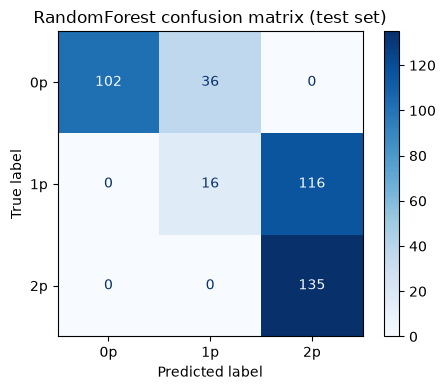

In [ ]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, rf_pred, display_labels=[LABEL_NAMES[c] for c in sorted(set(y_test))], ax=ax, cmap="Blues"
)
ax.set_title("RandomForest confusion matrix (test set)")
fig.tight_layout()
fig.savefig("confusion_matrix.png", dpi=150)
plt.show()